### Download and extract MovieLens 32M dataset

This dataset will be downloaded and extracted into the `data` folder located one level above the current notebook directory.

In [1]:
import requests
import zipfile
import os

url = "https://files.grouplens.org/datasets/movielens/ml-32m.zip"
output_path = "../ml-32m.zip"

# Download
r = requests.get(url, stream=True)
with open(output_path, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        f.write(chunk)

# Extract into parent directory
with zipfile.ZipFile(output_path, "r") as zip_ref:
    zip_ref.extractall("../data")

os.remove(output_path)

print("Download complete")
print(r"Extracted to MovieLens-Recommender\data")

Download complete
Extracted to MovieLens-Recommender\data


### Load and prepare the MovieLens 32M ratings data

This cell loads the MovieLens 32M ratings dataset and constructs dictionaries containing ratings grouped by user and by movie. These structures provide efficient access patterns for collaborative filtering algorithms and subsequent recommendation model development.

In [1]:
from collections import defaultdict
import pandas as pd

# Load data from file
ratings = pd.read_csv("../data/ml-32m/ratings.csv")

# Initialize dictionaries to store ratings by user and by movie
user_ratings = defaultdict(list)
movie_ratings = defaultdict(list)

# Populate dictionaries from ratings DataFrame
for row in ratings.itertuples(index=False):
    user_id = row.userId
    movie_id = row.movieId
    rating = row.rating

    user_ratings[user_id].append((movie_id, rating))
    movie_ratings[movie_id].append((user_id, rating))

### Visualise rating distribution

This cell computes the frequency of each rating value in the MovieLens 32M dataset and visualises the distribution as a bar chart.

An interesting feature of the distribution is that whole-number ratings (such as 3, 4, and 5) occur substantially more frequently than intermediate half-step ratings (such as 1.5, 2.5, or 3.5). This reflects common user rating behaviour, where users tend to favour rounded evaluations over more granular scoring choices.

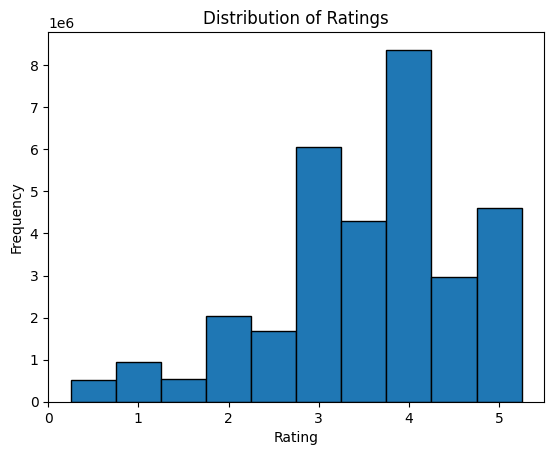

In [2]:
from collections import Counter
import matplotlib.pyplot as plt

# Count frequency of each rating
rating_counts = Counter(ratings['rating'])
x = sorted(rating_counts.keys())
y = [rating_counts[r] for r in x]

# Plot rating distribution
plt.bar(x, y, width=0.5, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings')
plt.show()

### Analyse user rating activity

This cell measures the number of ratings contributed by each user and visualises the distribution using a histogram with a logarithmic frequency scale.

The distribution is typically highly skewed: most users contribute relatively few ratings, while a small minority of highly active users provide very large numbers of ratings. Such long-tailed behaviour is common in recommender system datasets and has important implications for model training and generalisation.

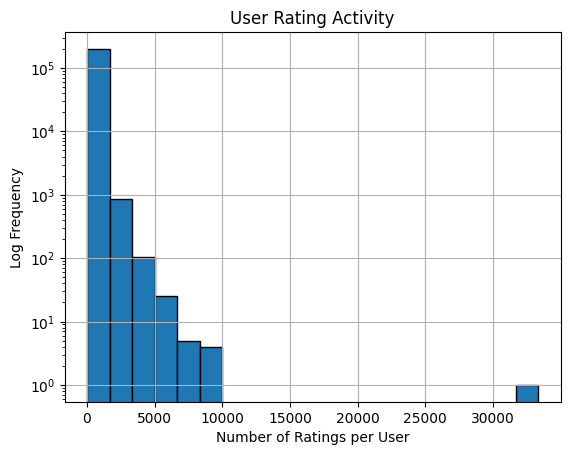

In [3]:
# Compute number of ratings per user
user_activity = [len(user_ratings[u]) for u in user_ratings]

# Plot histogram of user activity
plt.hist(user_activity, bins=20, log=True, edgecolor='black')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Log Frequency')
plt.title('User Rating Activity')
plt.grid(True)
plt.show()

### Analyse movie popularity

This cell measures how many ratings each movie receives and visualises the resulting popularity distribution using a histogram with a logarithmic frequency scale.

As with user activity, movie popularity exhibits a strong long-tailed structure. A relatively small number of movies accumulate very large numbers of ratings, while most movies receive comparatively limited attention. This imbalance is a central characteristic of real-world recommendation datasets and contributes to sparsity challenges in collaborative filtering models.

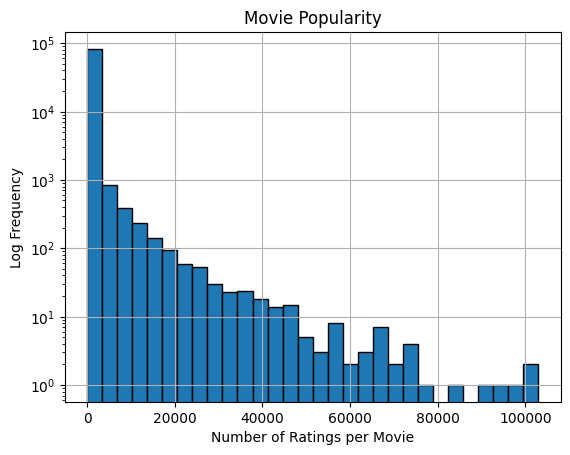

In [4]:
# Compute number of ratings per movie
movie_popularity = [len(movie_ratings[m]) for m in movie_ratings]

# Plot histogram of movie popularity
plt.hist(movie_popularity, bins=30, log=True, edgecolor='black')
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Log Frequency')
plt.title('Movie Popularity')
plt.grid(True)
plt.show()

### User activity on a log-log scale

This cell plots user activity against user rank on logarithmic axes. Users are ordered from most active to least active, allowing the heavy-tailed structure of the dataset to be examined more clearly.

The approximately linear behaviour on the log-log plot suggests power-law-like behaviour in user activity. In practice, this means that a very small number of users contribute extremely large numbers of ratings, while the overwhelming majority remain only modestly active. Such scaling behaviour is frequently observed in large online platforms and recommendation datasets.

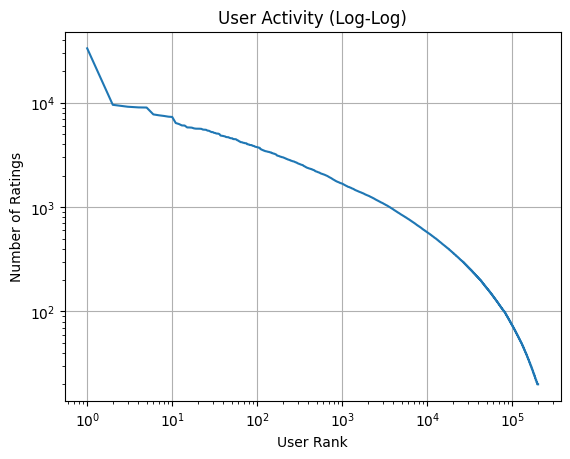

In [5]:
# Compute number of ratings per user
user_activity = [len(user_ratings[u]) for u in user_ratings]

# Sort user activity in descending order
user_activity_sorted = sorted(user_activity, reverse=True)

# Plot log-log user activity
plt.loglog(range(1, len(user_activity_sorted) + 1), user_activity_sorted)
plt.xlabel('User Rank')
plt.ylabel('Number of Ratings')
plt.title('User Activity (Log-Log)')
plt.grid(True)
plt.show()


### Movie popularity on a log-log scale

This cell plots movie popularity against movie rank on logarithmic axes, with movies ordered from most rated to least rated.

The near-linear structure on the log-log plot is indicative of power-law-like behaviour in movie popularity. A small subset of highly popular films attracts a disproportionately large share of ratings, whereas the majority of movies receive relatively limited engagement. This concentration of attention is a defining characteristic of many recommendation and online interaction systems.

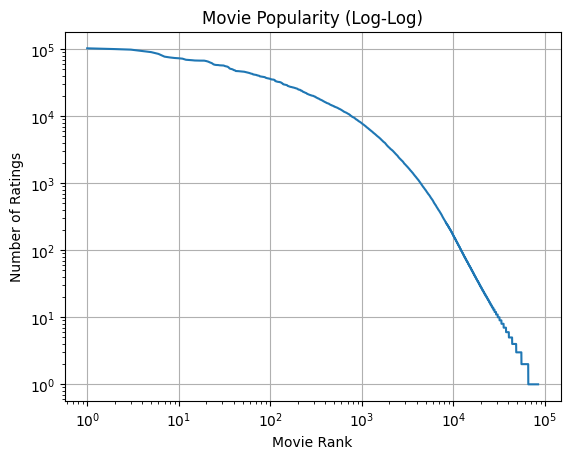

In [6]:
# Sort movie popularity in descending order
movie_popularity_sorted = sorted(movie_popularity, reverse=True)

# Plot log-log movie popularity
plt.loglog(range(1, len(movie_popularity_sorted) + 1), movie_popularity_sorted)
plt.xlabel('Movie Rank')
plt.ylabel('Number of Ratings')
plt.title('Movie Popularity (Log-Log)')
plt.grid(True)
plt.show()


### Comparing user and movie rating distributions

This cell compares the distributions of user activity and movie popularity on the same log-log plot.

For movies, the plot shows how many films receive a given number of ratings. For users, it shows how many users contribute a given number of ratings. Displaying both distributions together highlights the heavy-tailed and approximately power-law-like structure present on both sides of the recommendation system.

Such behaviour reflects an important property of large-scale collaborative filtering datasets: a small number of highly active users and highly popular items dominate interactions, while the majority remain comparatively sparse.

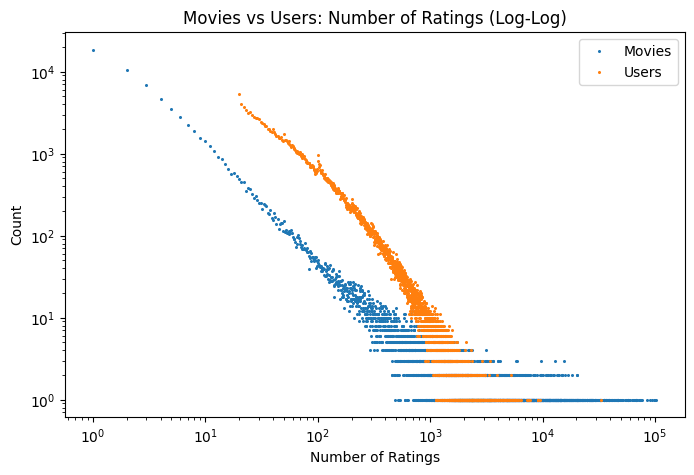

In [16]:
# Movie distribution
movies_per_rating_count = Counter(movie_popularity)
x_movies = sorted(movies_per_rating_count.keys())
y_movies = [movies_per_rating_count[r] for r in x_movies]

# User distribution
users_per_rating_count = Counter(user_activity)
x_users = sorted(users_per_rating_count.keys())
y_users = [users_per_rating_count[r] for r in x_users]

# Combined log-log plot
plt.figure(figsize=(8, 5))
plt.loglog(x_movies, y_movies, marker='o', markersize=1.2, linestyle='none', label='Movies')
plt.loglog(x_users, y_users, marker='o', markersize=1.2, linestyle='none', label='Users')

plt.xlabel('Number of Ratings')
plt.ylabel('Count')
plt.title('Movies vs Users: Number of Ratings (Log-Log)')
plt.legend()
plt.show()
